# Noise

## Lets look at the noise properties of an image

## Lets compare it with the theory - Poisson statistics - Gaussian random noise

## To get started we need to load some images 

In [1]:
# To use astropy we need to import libraries 


import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.time import Time
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
from scipy.ndimage import shift

import os
import gc             

In [2]:
# Get a list of processed CCD science images and print them to the screen 

images = ccdproc.ImageFileCollection('./',glob_include = 'procN*fits')
for filename in images.files_filtered():
    print(filename)
    

procNGC_3293_V_00003277.fits
procNGC_3293_V_00003280.fits
procNGC_3293_V_00003284.fits
procNGC_3293_V_00003388.fits
procNGC_3293_V_00003392.fits


In [3]:
# Load all of the images in the list 

scim=[]
for filename in images.files_filtered():
    scim.append(CCDData.read(filename, unit = "adu"))


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


1004.6853676626004 1714.712527863078


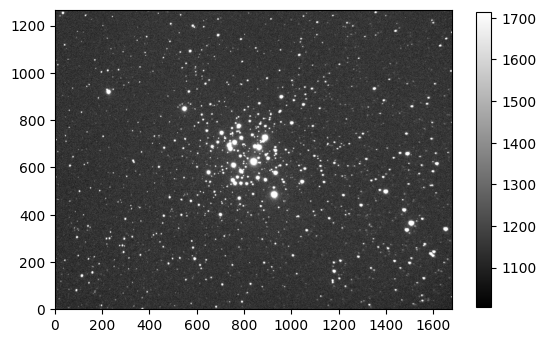

In [4]:
# Display the image using the 1st and 99th percentiles to define the black-white range

idx=0  # Index

p1=np.percentile(scim[idx].data, 1)
p99=np.percentile(scim[idx].data, 99)
print(p1,p99)

plt.imshow(scim[idx].data, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)

# Display a relatively blank region

1159.9260816957258
1004.6853676626004 1714.712527863078


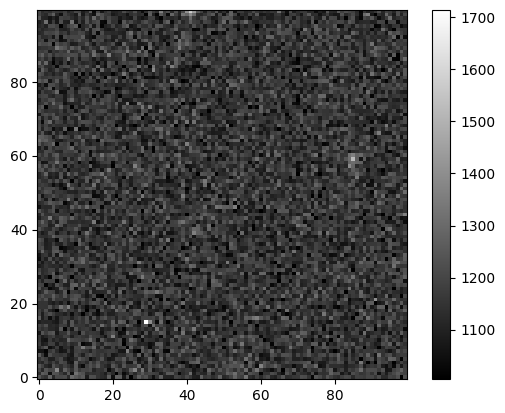

In [5]:
# Zoom in on a relatively blank region


idx=0  # Index
med=np.median(scim[idx].data)
print(med)
p1=np.percentile(scim[idx].data, 1)
p99=np.percentile(scim[idx].data, 99)
print(p1,p99)

skydata=scim[idx].data[845:945,250:350]

plt.imshow(skydata, cmap='gray', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=1.0)

# Plot a histogram of the data

Median 1155.7716147212545
Standard Deviation 67.59819446589228


Text(0.5, 1.0, 'Histogram of pixels values in sky region')

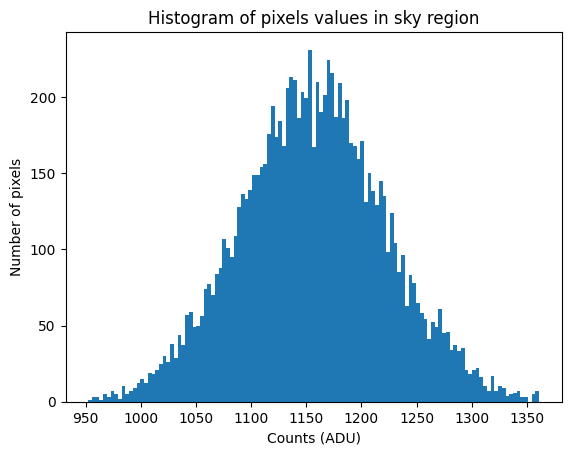

In [6]:

# Define the bins from the histogram around the median
med=np.median(skydata)
print('Median', med)

# Standard deviation
std=np.std(skydata)
print('Standard Deviation', std)

# Histogram bins from -3 to +3 standard deviations (-3 to +3 sigma)
bins=[int(med)-3.0*std]
while bins[-1]<int(med)+3.0*std:
    bins.append(bins[-1]+0.05*std)

# Convert the 2-d image data into a 1-d list or array
data1d=[]
for row in skydata:
    data1d.extend(row)

plt.hist(data1d, bins)
plt.xlabel('Counts (ADU)')
plt.ylabel('Number of pixels')
plt.title('Histogram of pixels values in sky region')

# Photon noise distribution from theory

### Photons closely approximate Poisson statistics 

\begin{equation}
P = \frac{\lambda ^k e^{-k}}{ k!} 
\end{equation}

where $P$ is the probabilty, $\lambda$ the mean and $k$ the number of events. 

For example, $\lambda$ is the mean number of background photons per pixel and $k$ is the individual number of photons in a given pixel.

### While photons may arrive at a particular rate on average, individual don't arrive at fixed time intervals

### The probabilty of a photon arriving at a detector in a given instant does not depend on the time since the previous photon arrived

### When the number of photons is high (e.g. 100 or more) then Poisson statistics are approximately Gaussian

### When the number of photons is high, the standard deviation is the square root of the number of photons

### See Section 1.5.3 from Rieke

# Signal-to-noise

### We quantify the quality of our detections with signal-to-noise

### Signal would be the number of source of photons (excluding night sky photons)

### Signal is the celestial source photons

### Photon noise would be the noise determined from all photons (source and sky photons)


# Simple example with source photons only

### We detect, on average, 100 source photons in each exposure

### We don't have any other significiant sources of noise 

### The noise will be the 10, the square root of 100, and the signal-to-noise will be 10

# Simple example with source and sky photons 

### Within some region we detect ~100 source photons and ~9900 sky photons

### What is the signal? 100 photons.

### What is the noise? Sky + Source is 10,000 photons - square root of 10,000 is 100. Noise is 100. 

### What is the signal-to-noise? 100 divided 100 - so our signal-to-noise is 1.

# What happens when we combine 9 images together (sum or average)

### Within some region we now detect ~900 source photons and ~89100 sky photons

### What is the signal? 900.

### What is the noise? Source + Sky - 900 + 89100 = 90000. Square root of 90,000 is 300. 

### What is the signal-to-noise? 3 

### As we can see, we have increased the signal-to-noise to approach significance

### As we can see, we can detect a source that is fainter than the background sky

# We can compare theory with observation

### The catch is our image is in arbitrary units - analog-to-digital units (ADUs)

### We need to determine the number of detected photons (or electrons - one electron per photon for a CCD)

### We need the conversion factor, which is the Gain (electrons per ADU)

### Fortunately there is a Gain keyword in the header of the images


In [8]:
print(scim[idx].header)
print('\n\n')
egain=scim[0].header['EGAIN']
print('Gain (e/ADU)', egain)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1679                                                  NAXIS2  =                 1268                                                  EXTEND  =                    T                                                  COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H OBSERVER= 'Monash C11 Observer' / SBIGFITSEXT The name of the observer          ORIGIN  = 'Monash C11'         / Description of location                        TELESCOP= 'C11     '           / SBIGFITSEXT The model Telescope                FOCALLEN=                 279. / SBIGFITSEXT Telescope focal length in mm       APTDIA  =                 280. / SBIGFIT

In [9]:
# Let's do the stats again

med=np.median(skydata)
print('Median (ADU)', med)

std=np.std(skydata)
print('Standard Deviation (ADU)', std)

emed=np.median(skydata)*egain
print('Median (electrons)', emed)

estd=np.std(skydata)*egain
print('Standard Deviation (electrons)', estd)

print('Square root of the median (electrons)', emed**0.5)



Median (ADU) 1155.7716147212545
Standard Deviation (ADU) 67.59819446589228
Median (electrons) 439.1932135940767
Standard Deviation (electrons) 25.687313897039065
Square root of the median (electrons) 20.956937123398465


# Comment

### Are sky photons the only source of noise? 

### No, we also have amplifier noise 

### Dark contribute noise too (but not very much in modern detectors)

# Bias images and readout noise (read noise)

## Read noise does not follow Poisson stars

## Read noise does not originate from the arrival of photons or ejection of electrons 

## It is approximately Gaussian 

## It is added in quadrature to other sources of noise 

In [10]:
images = ccdproc.ImageFileCollection('./',glob_include = 'Bias*fits')
for filename in images.files_filtered():
    print(filename)

# Load all of the images in the list 

bias=[]
for filename in images.files_filtered():
    bias.append(CCDData.read(filename, unit = "adu"))


Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'. [astropy.wcs.wcs]
Set OBSGEO-Y to  2879792.379 from OBSGEO-[LBH].
Set OBSGEO-Z to -3897419.410 from OBSGEO-[LBH]'.


Bias_00002830.fits
Bias_00002835.fits
Bias_00002840.fits
Bias_00002845.fits
Bias_00002850.fits


1831.0 2018.0


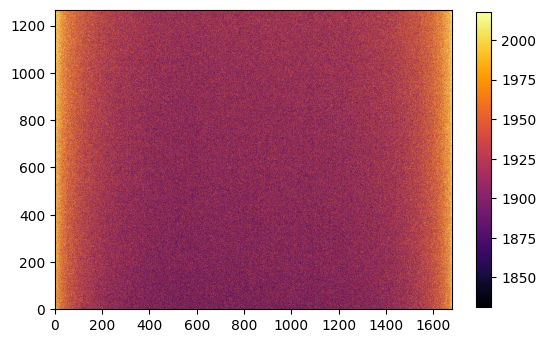

In [12]:
# Display the image using the 1st and 99th percentiles to define the black-white range

idx=0  # Index

p1=np.percentile(bias[idx].data, 1)
p99=np.percentile(bias[idx].data, 99)
print(p1,p99)

plt.imshow(bias[idx].data, cmap='inferno', vmin=p1, vmax=p99)
ax = plt.gca()
ax.invert_yaxis()
plt.colorbar(shrink=0.8)

In [13]:
# Let's do the stats again

biasregion=bias[idx].data[600:800,600:800]  # Choose a region away from the edges

bmed=np.median(biasregion)
print('Bias Median (ADU)', bmed)

bstd=np.std(biasregion)
print('Bias Standard Deviation (ADU)', bstd)

ebmed=np.median(biasregion)*egain
print('Bias Median (electrons)', ebmed)

ebstd=np.std(biasregion)*egain
print('Bias Standard Deviation (electrons)', ebstd)

print('Bias Square root of the median (electrons)', ebmed**0.5)


Bias Median (ADU) 1904.0
Bias Standard Deviation (ADU) 33.80262460090932
Bias Median (electrons) 723.52
Bias Standard Deviation (electrons) 12.844997348345542
Bias Square root of the median (electrons) 26.898327085527086


# Comment

# <font color='red'> MAJOR POINT: Noise in bias images does not follow Poisson stats </font>

### The source of noise in bias images is not the arrival of individual photons

# Combine photon (Poisson) noise and read noise for the science image 

### Add read noise and expected photon (Poisson) noise in quadrate 

$\sigma_{tot}^2 = \sigma_1^{2} + \sigma_2^2$

### Read noise measured from the bias

### Expected Poisson noise is square root of the science background in electrons

### Note all the calculations are in detected photons or electrons, not ADU

### Poisson stats apply to individual events (the arrival of photons), not some arbitrarily scaled number

In [14]:
# Add the measure read noise and expected poisson noise in quadrate 

enoise = (ebstd**2 + (emed**0.5)**2)**0.5
print('Expected noise in science image from read noise and square root of background in electrons (in electrons)', enoise)

print('Measured noise in science image (in electrons)', estd)

Expected noise in science image from read noise and square root of background in electrons (in electrons) 24.580219089200178
Measured noise in science image (in electrons) 25.687313897039065


### Note: We have assumed no noise in the combined bias, dark and flats

# Can we do Poisson stats in ADUs?

# <font color='red'> MAJOR POINT: NO </font>



In [15]:
# Poisson stats in ADU doesn't work

wnoise = (bstd**2 + (med**0.5)**2)**0.5
print('Wrong noise in science image from read noise and square root of background in ADU (in ADU)', wnoise)

print('Measured noise in science image (in ADU)', std)

Wrong noise in science image from read noise and square root of background in ADU (in ADU) 47.94151692042352
Measured noise in science image (in ADU) 67.59819446589228
